## 1.Import necessary Libraries 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## 2.Import Dataset

In [15]:
mail_data=pd.read_csv("mail_data.csv")
mail_data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## 3. Data understanding

In [16]:
mail_data.shape

(5572, 2)

In [17]:
mail_data.isna().sum()

Category    0
Message     0
dtype: int64

#### In this Data set there is no null entries

In [18]:
mail_data.duplicated().sum()

np.int64(415)

In [19]:
duplicates=mail_data[mail_data.duplicated(keep=False)]
duplicates.sort_values(by="Message")

,Category,Message
2124,spam,#ERROR!
717,spam,#ERROR!
505,spam,#ERROR!
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
...,...,...
1381,ham,i dnt wnt to tlk wid u
4004,ham,somewhere out there beneath the pale moon ligh...
1412,ham,somewhere out there beneath the pale moon ligh...
2389,ham,wiskey Brandy Rum Gin Beer Vodka Scotch Shampa...


In [20]:
mail_data.drop_duplicates(inplace=True)

In [21]:
mail_data.duplicated().sum()

np.int64(0)

In [22]:
mail_data.shape

(5157, 2)

#### After, Drop the duplicates the dataset contains 5157 observations across 2 parameters

In [23]:
mail_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   object
 1   Message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [24]:
email_data.value_counts()

Category  Message                                                                                                                                                                     
ham       Sorry, I'll call later                                                                                                                                                          30
          I cant pick the phone right now. Pls send a message                                                                                                                             12
          Ok...                                                                                                                                                                           10
          Okie                                                                                                                                                                             4
          Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,C

### 4.Exploratory Data Analysis

#### 4.1 Class distribution chart

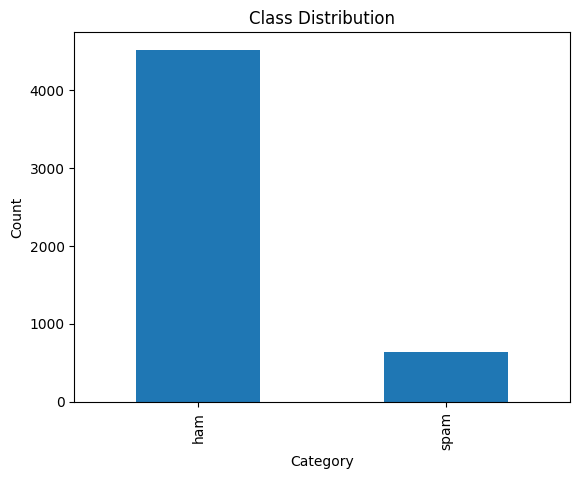

In [27]:
mail_data["Category"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

#### 4.2 Analyse the Message length

In [28]:
mail_data["Message_lenghth"]=mail_data["Message"].apply(len)

In [29]:
mail_data.head()

,Category,Message,Message_lenghth
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


##### Now,check the category wise average length 

In [30]:
mail_data.groupby(by="Category")["Message_lenghth"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_lenghth, dtype: float64

##### Here,we can understand clearly understand the spam message length was to high compared to normal message

#### Visualization

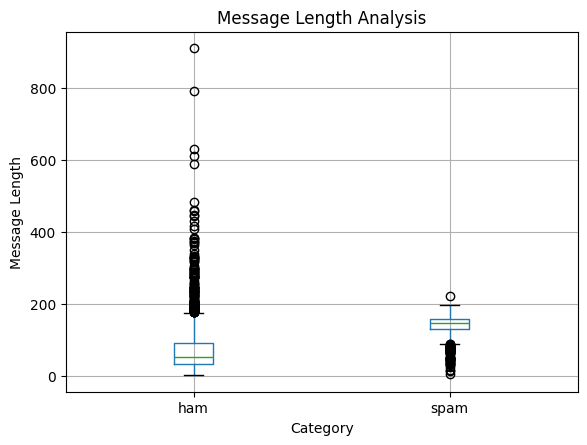

In [32]:
mail_data.boxplot(column="Message_lenghth",by="Category")
plt.ylabel("Message Length")
plt.suptitle("")
plt.title("Message Length Analysis")
plt.show()